In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from Kmeans_scratch import KMeansScratch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
train=pd.read_csv("unsupervised_data.csv")
# drop ID
X = train.drop(columns="ID",axis=1)
X = X.astype("float16")


In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [4]:
model = KMeansScratch(n_clusters=8, random_state=42)
model.fit(X_scaled)

#labels = model.labels_
#score = silhouette_score_scratch(X_scaled, labels)

print("Centroids:\n", model.centroids_)
#print("Silhouette:", round(score, 4))

Centroids:
 [[-1.505    1.119    0.623    0.7534  -1.073    1.578  ]
 [ 0.743   -0.909   -1.429    1.658    2.01     1.056  ]
 [-0.2769   1.362    1.116    0.351   -0.635   -1.053  ]
 [ 0.07916  0.883   -0.916    0.03125  0.7896  -1.402  ]
 [-1.82     1.116    0.6143   0.7637  -1.079    1.583  ]
 [ 1.727   -0.7817  -0.9854  -1.2     -0.1494   0.14   ]
 [-0.02339 -0.556    0.6597  -1.359   -0.189   -0.3716 ]
 [-0.585   -1.116    0.934   -0.2399  -0.7495   0.05048]]


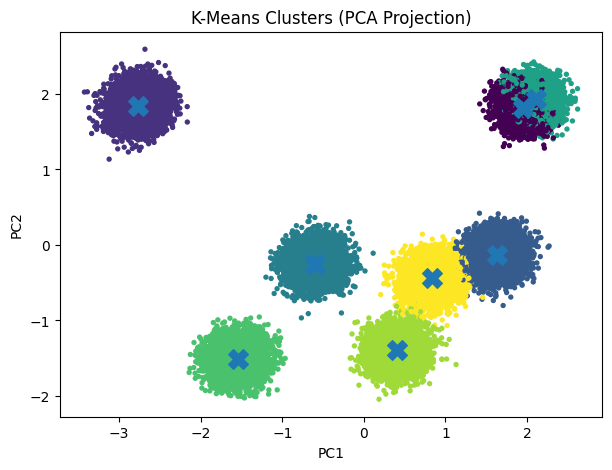

In [5]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled)
centroids2 = pca.transform(model.centroids_)

plt.figure(figsize=(7,5))
plt.scatter(X2[:,0], X2[:,1], c=model.labels_, s=8)
plt.scatter(centroids2[:,0], centroids2[:,1], marker='X', s=200)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")
plt.show()